# 03 · Survivorship-free screening

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/03_survivorship_free_screening.ipynb)

**What you will learn**

- What survivorship bias is, and how large it is on a real index over a few years.
- How to rebuild the S&P 500 exactly as it stood on a past date (`client.pit_universe`,
  `client.universe`).
- How to screen that historical universe on ratios that were public on that date
  (`client.signal_panel`).

**Plan required:** none (free sample tier). The sample covers S&P 500 companies, including the
ones that left the index, for the last five years. Benchmark (free with sign-up) extends the
same universe back to 1993; Pro and Institutional cover every SEC filer, delisted ones included.

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The problem

"Take today's S&P 500 and test my strategy over the last five years" quietly drops every
company that was in the index five years ago and is not today: acquired, merged, shrunk out of
the index, or bankrupt. The companies that remain are, by construction, the ones that did well
enough to stay. Any result computed on them is flattered.

The fix is to ask the question as of the past date: who was a member *then*?

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()
START = "2022-06-30"

members = client.pit_universe(START)
left = members[members["removal_date"].notna()]
print(f"S&P 500 members on {START}: {len(members)}")
print(f"of which have since left the index: {len(left)}")
left[["cik", "company_name", "ticker_at_date", "sector", "removal_date"]].sort_values("removal_date").head(10)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


S&P 500 members on 2022-06-30: 496
of which have since left the index: 71


,cik,company_name,ticker_at_date,sector,removal_date
354,0000921738,"PENN Entertainment, Inc.",PENN,Consumer Discretionary,2022-09-19
372,0000078239,PVH CORP. /DE/,PVH,Consumer Discretionary,2022-09-19
151,0000783280,DUKE REALTY CORP,DRE,Financials,2022-10-03
102,0000877890,CITRIX SYSTEMS INC,CTXS,Information Technology,2022-10-03
340,0001492633,Nielsen Holdings plc,NLSN,Industrials,2022-10-12
442,0001418091,"TWITTER, INC.",TWTR,Information Technology,2022-11-01
200,0001519751,"Fortune Brands Innovations, Inc.",FBIN,Materials,2022-12-19
2,0000815094,ABIOMED INC,ABMD,Health Care,2022-12-22
465,0000899689,VORNADO REALTY TRUST,VNO,Financials,2023-01-04
418,0000719739,SVB FINANCIAL GROUP,SIVB,Financials,2023-03-15


`pit_universe` returns one row per member with the ticker it traded under **on that date**
(`ticker_at_date`), which can differ from today's ticker. Join on `cik`, never on the ticker.

## 2. Screen the universe as it was

`client.universe()` resolves membership at one or more dates. `client.signal_panel()` then
attaches, for each member and date, the latest ratio vintage with `accepted_at` on or before
that date: what a screen run that day would have seen. `include_price=False` skips prices,
which keeps this step on the tables every plan has.

Ratio names come from the `ratio` table (`SELECT DISTINCT ratio_name FROM ratio`). Ratios
are decimals: `0.25` is 25%. The free sample holds fiscal years from 2021 on, so its first
ratios became public during 2021 and early 2022: on the sample, pick screen dates from mid-2022.

In [3]:
universe = client.universe(dates=[START])
panel = client.signal_panel(
    universe,
    ratios=["return_on_equity", "net_margin", "debt_to_equity"],
    include_price=False,
)
print(len(panel), "members;", panel["return_on_equity"].notna().sum(), "with a known ROE on", START)

screen = panel[
    (panel["return_on_equity"] > 0.20)
    & (panel["net_margin"] > 0.15)
    & (panel["debt_to_equity"].between(0, 1.5))
].sort_values("return_on_equity", ascending=False)
screen["left_index_later"] = screen["index_removal_date"].notna()
print(len(screen), "companies pass the screen")
screen[["ticker", "name", "sector", "return_on_equity", "net_margin", "debt_to_equity",
        "left_index_later"]].head(15).round(3)

496 members; 355 with a known ROE on 2022-06-30
54 companies pass the screen


,ticker,name,sector,return_on_equity,net_margin,debt_to_equity,left_index_later
227,IDXX,IDEXX LABORATORIES INC /DE,Health Care,1.126,0.232,1.232,False
190,FTNT,"Fortinet, Inc.",Information Technology,0.734,0.182,1.238,False
274,LRCX,LAM RESEARCH CORP,Industrials,0.698,0.267,0.828,False
444,TXN,TEXAS INSTRUMENTS INC,Information Technology,0.690,0.424,0.581,False
327,NOC,NORTHROP GRUMMAN CORP /DE/,Health Care,0.596,0.196,0.988,False
222,HSY,HERSHEY CO,Consumer Staples,0.592,0.165,1.482,False
384,REGN,"REGENERON PHARMACEUTICALS, INC.",Health Care,0.542,0.502,0.105,False
215,HOLX,HOLOGIC INC,Health Care,0.540,0.332,0.717,True
27,AMAT,APPLIED MATERIALS INC /DE,Information Technology,0.516,0.255,0.445,False
495,ZTS,Zoetis Inc.,Health Care,0.490,0.262,1.451,False


Some names that passed the screen in 2022 are no longer in the index. A screen run on today's
membership list could never have selected them, which is exactly the bias.

## 3. How big is the bias?

Compare the equal-weight total return from the start date to the latest month-end for:

- **all members on the start date** (the honest universe), and
- **only those still members today** (the survivor-only universe most tutorials use).

Returns use `total_return_index` from the `stock_price` table (month-end closes on the free
tiers), which includes dividends and splits. A company whose shares stopped trading is held to
its last month-end close.

In [4]:
returns = client.run_query(f"""
    WITH bars AS (
        SELECT entity_id, price_date, total_return_index AS tri
        FROM stock_price
        WHERE observation = 'monthly'
        -- a company with two share classes has two price series: keep one per month
        QUALIFY ROW_NUMBER() OVER (PARTITION BY entity_id, price_date ORDER BY security_id) = 1
    ),
    start_px AS (
        SELECT entity_id, arg_max(tri, price_date) AS tri_start
        FROM bars WHERE price_date <= DATE '{START}' GROUP BY entity_id
    ),
    end_px AS (
        SELECT entity_id, arg_max(tri, price_date) AS tri_end, max(price_date) AS last_bar
        FROM bars GROUP BY entity_id
    )
    SELECT m.cik, s.tri_start, e.tri_end, e.last_bar
    FROM (SELECT DISTINCT cik FROM index_membership
          WHERE index_name = 'SP500' AND effective_date <= DATE '{START}'
            AND (removal_date IS NULL OR removal_date > DATE '{START}')) m
    LEFT JOIN start_px s ON s.entity_id = m.cik
    LEFT JOIN end_px e ON e.entity_id = m.cik
""")
returns = returns.merge(members[["cik", "removal_date"]].drop_duplicates("cik"), on="cik", how="left")
returns["still_member"] = returns["removal_date"].isna()
returns["total_return"] = returns["tri_end"] / returns["tri_start"] - 1

priced = returns.dropna(subset=["total_return"])
print(f"members with a price at both ends: {len(priced)} of {len(returns)}")
summary = pd.Series({
    "all members on start date": priced["total_return"].mean(),
    "only today's survivors": priced.loc[priced["still_member"], "total_return"].mean(),
    "only the ones that left": priced.loc[~priced["still_member"], "total_return"].mean(),
})
summary.map("{:+.1%}".format)

members with a price at both ends: 496 of 496


all members on start date    +79.1%
only today's survivors       +94.3%
only the ones that left      -11.7%
dtype: str

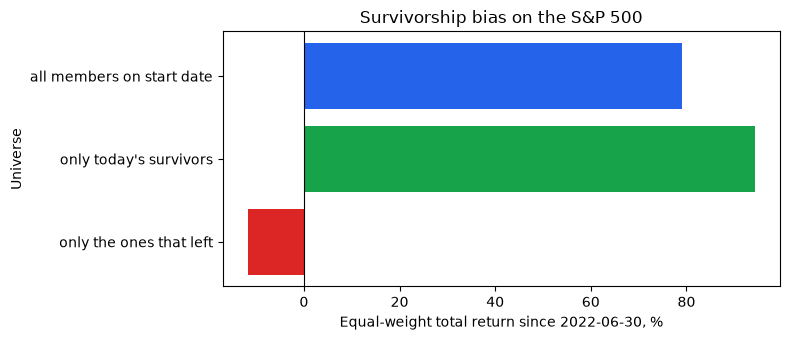

Survivor-only minus honest universe: +15.2 percentage points


In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#2563eb", "#16a34a", "#dc2626"]
ax.barh(summary.index, summary.values * 100, color=colors)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Equal-weight total return since {START}, %")
ax.set_ylabel("Universe")
ax.set_title("Survivorship bias on the S&P 500")
plt.tight_layout()
plt.show()

gap = (summary.iloc[1] - summary.iloc[0]) * 100
print(f"Survivor-only minus honest universe: {gap:+.1f} percentage points")

The gap is the survivorship bias of this window. It grows with the length of the backtest and
with the turnover of the universe you draw from; for the full US market, where delistings are
far more common than in the S&P 500, it is larger.

## 4. Rules to copy into your own code

1. Build the universe at each rebalance date from `index_membership`
   (`effective_date <= d < removal_date`), or call `client.universe(dates=...)`.
2. Keep companies that later left: `entity.status = 'INACTIVE'` rows and securities with a
   `valid_to` are history, not noise.
3. Join on `cik`. Tickers get reused.
4. Hold a delisted name to its last trade instead of dropping it from the return series.

In [6]:
client.close()

## Next steps

- **[04 · Point-in-time factor backtest](04_pit_factor_backtest.ipynb)**: turn this universe
  and a signal into a quantile backtest with costs.
- Script versions: [`python/entity_screening.py`](../python/entity_screening.py) and
  [`python/survivorship_bias.py`](../python/survivorship_bias.py).